<a href="https://colab.research.google.com/github/sneha-chira/OCR/blob/master/End%20to%20end%20toy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [4]:
df=pd.read_csv('/content/placement (1).csv')

In [5]:
df.head()

,Unnamed: 0,cgpa,iq,placement
0,0,6.8,123.0,1
1,1,5.9,106.0,0
2,2,5.3,121.0,0
3,3,7.4,132.0,1
4,4,5.8,142.0,0


In [6]:
df.shape

(100, 4)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  100 non-null    int64  
 1   cgpa        100 non-null    float64
 2   iq          100 non-null    float64
 3   placement   100 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 3.3 KB


In [9]:
df=df.iloc[:,1:]

In [10]:
df

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0
...,...,...,...
95,4.3,200.0,0
96,4.4,42.0,0
97,6.7,182.0,1
98,6.3,103.0,1


In [11]:
import matplotlib.pyplot as plt


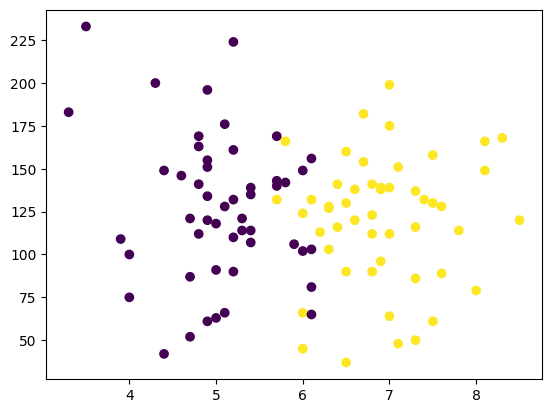

In [14]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [18]:
X=df.iloc[:,0:2]
y=df.iloc[:,2:]

In [19]:
X

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [20]:
y

,placement
0,1
1,0
2,0
3,1
4,0
...,...
95,0
96,0
97,1
98,1


In [21]:
y.shape

(100, 1)

In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1)

In [25]:
X_train

,cgpa,iq
85,5.8,166.0
88,4.4,149.0
32,7.0,139.0
8,6.1,156.0
84,5.7,169.0
...,...,...
41,5.4,114.0
69,8.5,120.0
34,4.8,163.0
92,5.2,110.0


In [26]:
y_train

,placement
85,1
88,0
32,1
8,0
84,0
...,...
41,0
69,1
34,0
92,0


In [27]:
from sklearn.preprocessing import StandardScaler

In [28]:
scaler=StandardScaler()

In [42]:
X_train=scaler.fit_transform(X_train)

In [43]:
X_train

array([[-0.14664547,  1.16429878],
       [-1.40360667,  0.72715102],
       [ 0.93074984,  0.47000528],
       [ 0.12270336,  0.90715304],
       [-0.23642842,  1.24144251],
       [-2.21165316,  2.88717526],
       [ 0.12270336, -1.43287323],
       [-0.95469196,  0.88143847],
       [ 1.28988161,  0.29000326],
       [ 0.48183513,  1.01001134],
       [-1.0444749 ,  0.52143442],
       [-1.13425784, -0.86715259],
       [ 0.39205218,  0.52143442],
       [ 1.4694475 ,  0.18714496],
       [ 0.48183513,  0.23857411],
       [ 0.03292041, -0.48143398],
       [ 1.91836221,  1.16429878],
       [-0.77512607,  1.42144453],
       [-0.05686253, -0.37857568],
       [-0.50577724,  0.36714698],
       [-0.95469196, -0.01857164],
       [ 0.2124863 , -0.19857366],
       [ 1.02053278, -1.87002099],
       [-0.59556019,  0.00714294],
       [ 0.39205218, -0.12142993],
       [ 1.37966455, -1.53573152],
       [ 0.75118395, -0.22428823],
       [ 0.48183513, -0.79000887],
       [-0.95469196,

In [44]:
X_test=scaler.fit_transform(X_test)

In [45]:
X_test

array([[ 0.50406652, -0.27049032],
       [ 1.57329855,  0.49108437],
       [-0.79428664,  0.30725599],
       [-0.87066036, -2.18755763],
       [-2.24538725,  0.88500231],
       [ 0.35131909,  0.12342762],
       [ 0.04582423, -1.21589338],
       [ 0.50406652, -0.29675151],
       [ 0.58044024,  1.30518144],
       [ 0.35131909,  0.85874111]])

In [38]:
from sklearn.linear_model import LogisticRegression

In [39]:
clf=LogisticRegression()

In [61]:
clf.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression()

In [62]:
y_pred=clf.predict(X_test)

In [63]:
y_test

,placement
60,1
53,1
47,0
9,0
17,0
74,1
98,1
11,1
26,1
97,1


In [64]:
from sklearn.metrics import accuracy_score

In [65]:
accuracy_score(y_test,y_pred)

1.0

In [66]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

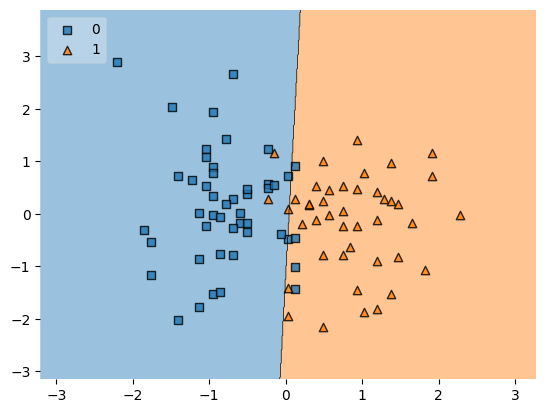

In [67]:
plot_decision_regions(X_train,y_train.values.ravel(),clf=clf,legend=2)

In [68]:
import pickle

In [69]:
pickle.dump(clf,open('model.pkl','wb'))